# One Tight One not Tight

In [2]:
%cd ..

/eos/home-i00/d/driosper/bsm3g_coffea


In [3]:
from coffea.util import load
import numpy as np
import mplhep as hep
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
from coffea.processor import accumulate
from hist.intervals import poisson_interval
from pathlib import Path
import yaml
from analysis.filesets.utils import get_process_maps
from analysis.workflows.config import WorkflowConfigBuilder
import json
import hist
import yaml
import numpy as np
import collections
from scipy.optimize import curve_fit
from scipy.stats import f as f_dist

In [4]:
def load_hists(year,workflow):
    out = load(f"outputs/{workflow}/{year}/{year}_processed_histograms.coffea")
    config_builder = WorkflowConfigBuilder(workflow=workflow)
    workflow_config = config_builder.build_workflow_config()
    postprocess_dir = Path.cwd() / "analysis" / "postprocess"
    style_file = postprocess_dir / "style.yaml"
    luminosity_file = postprocess_dir / "luminosity.yaml"
    color_map_file = postprocess_dir / "color_map.yaml"
    
    with open(style_file, "r") as f:
        style = yaml.safe_load(f)
    with open(f"{Path.cwd()}/analysis/postprocess/luminosity.yaml", "r") as f:
        luminosities = yaml.safe_load(f)
    processes, process_name_map, _ = get_process_maps(workflow_config, year)
    with open(color_map_file, "r") as f:
        color_map = yaml.safe_load(f)
    color_map = {p: c for p, c in color_map.items() if p in processes}
    
    hep.style.use(hep.style.CMS)
    plt.rcParams.update(style["rcParams"])
    return out
    
def poly_func(x, *coefs):
    return np.polyval(coefs, x)
def fit_polynomial(x, y, yerr, degree):
    p0 = np.ones(degree + 1)
    popt, pcov = curve_fit(
        poly_func, x, y, p0=p0, sigma=yerr, absolute_sigma=True, maxfev=10000
    )
    residuals = y - poly_func(x, *popt)
    chisq = np.sum((residuals / yerr) ** 2)
    ndof = len(x) - len(popt)
    
    return popt, pcov, chisq, ndof
def find_optimal_tf_poly(x, y, yerr, max_degree=5, alpha=0.05):
    n = len(x)
    
    # Fallback case if a year has completely empty/insufficient data points
    if n == 0:
        return 0, np.array([1.0]), np.array([[1.0]])

    # Start with a linear fit (2 parameters) if n >= 2, otherwise a constant fit (1 parameter)
    current_degree = 1 if n >= 2 else 0
    popt1, pcov1, chisq1, ndof1 = fit_polynomial(x, y, yerr, current_degree)
    
    for next_degree in range(current_degree + 1, max_degree + 1):
        # GUARD CLAUSE: To perform an F-test, the higher-degree model must 
        # have at least 1 degree of freedom left (n - (next_degree + 1) > 0)
        if next_degree >= n - 1:
            break
            
        try:
            popt2, pcov2, chisq2, ndof2 = fit_polynomial(x, y, yerr, next_degree)
        except RuntimeError:
            # Catch curve_fit convergence failures and stop searching higher degrees
            break
            
        p1 = current_degree + 1
        p2 = next_degree + 1
        
        numerator = (chisq1 - chisq2) / (p2 - p1)
        denominator = chisq2 / (n - p2)
        
        if denominator <= 0 or numerator < 0:
            break
            
        F_stat = numerator / denominator
        p_val = f_dist.sf(F_stat, p2 - p1, n - p2)
        
        if p_val < alpha:
            current_degree = next_degree
            popt1, pcov1, chisq1, ndof1 = popt2, pcov2, chisq2, ndof2
        else:
            break
            
    return current_degree, popt1, pcov1

In [5]:
procs_tf = ["DYJetsToLL", "SingleTop", "tt", "Diboson"]
out_tf = load_hists("2017", "qcd_tf_ele_SingleMu_weightedv2")
mc_tf_all = accumulate([out_tf[p]["transverse_mass"] for p in procs_tf if p in out_tf])
h_tf_base = out_tf["Data"]["transverse_mass"] + (mc_tf_all * -1)
h_Tight = h_tf_base[{"variation": "nominal", "category": "2T"}].project("electron_met_mass")
out_tf = load_hists("2017", "qcd_tf_ele_SingleMu")
mc_tf_all = accumulate([out_tf[p]["transverse_mass"] for p in procs_tf if p in out_tf])
h_tf_base = out_tf["Data"]["transverse_mass"] + (mc_tf_all * -1)
h_nTight = h_tf_base[{"variation": "nominal", "category": "1T1L"}].project("electron_met_mass")

In [6]:
h_Tight.values()

array([ 2.41017565e+03,  2.25138960e+03,  2.11297141e+03,  9.34083978e+02,
        6.12352425e+01, -6.74592435e-01, -2.99451601e+02, -8.09420017e+01,
       -2.29733396e+01])

In [7]:
h_nTight.values()

array([ 9400.61731264, 10433.23325807,  8735.12779554,  4621.00671675,
        2146.51831711,   996.66687899,  1535.8212756 ,   469.32853276,
          55.10140422])

In [8]:
np.where(
    (h_Tight.values() > 0) & (h_nTight.values() > 0), 
    h_Tight.values() / (h_nTight.values() + 1e-32),
    1
)

array([0.25638483, 0.21579021, 0.24189359, 0.20213863, 0.02852771,
       1.        , 1.        , 1.        , 1.        ])

### QCD TRANSFER FACTOR

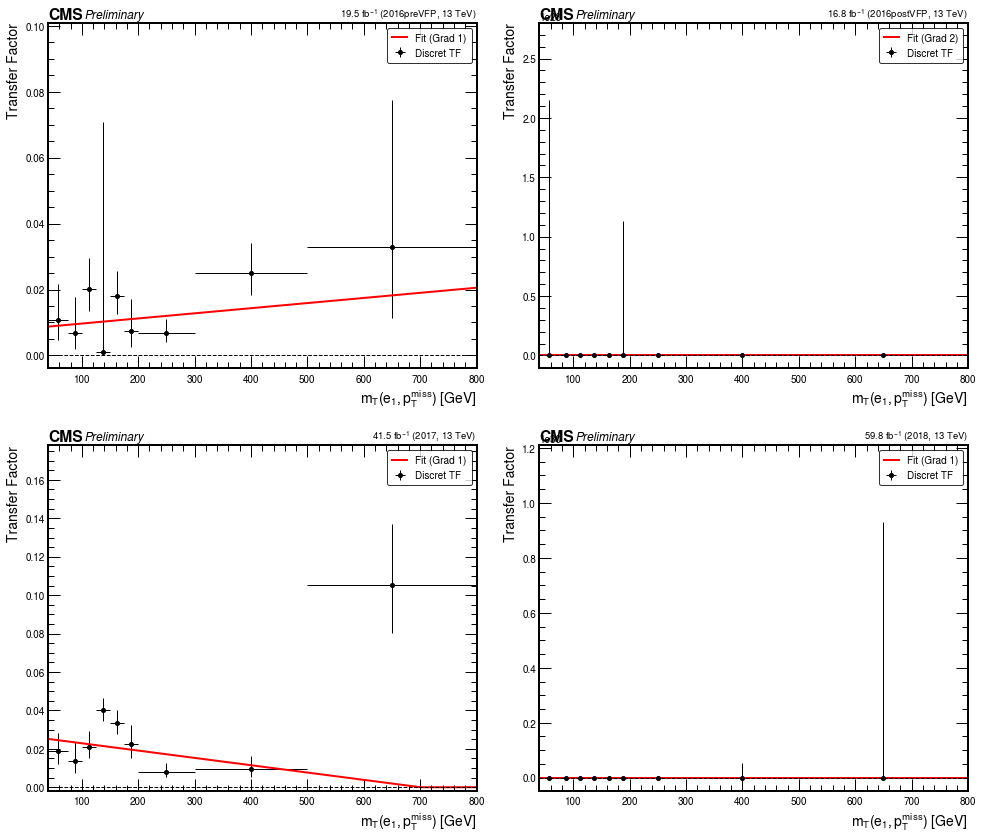

In [12]:
hep.style.use("CMS")
energy = {"run2": "13 TeV", "run3": "13.6 TeV"}
with open(f"{Path.cwd()}/analysis/postprocess/luminosity.yaml", "r") as f:
    luminosities = yaml.safe_load(f)
years = ["2016preVFP", "2016postVFP", "2017", "2018"]
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

def compute_tf_for_year(year_str):
    procs_tf = ["DYJetsToLL", "SingleTop", "tt", "Diboson"]
    out_tf = load_hists(year_str, "qcd_tf_ele")
    mc_tf_all = accumulate([out_tf[p]["transverse_mass"] for p in procs_tf if p in out_tf])
    h_tf_base = out_tf["Data"]["transverse_mass"] + (mc_tf_all * -1)
    h_Tight = h_tf_base[{"variation": "nominal", "category": "1LnT1T"}].project("electron_met_mass_leading")
    out_tf = load_hists(year_str, "qcd_tf_ele")
    mc_tf_all = accumulate([out_tf[p]["transverse_mass"] for p in procs_tf if p in out_tf])
    h_tf_base = out_tf["Data"]["transverse_mass"] + (mc_tf_all * -1)
    h_nTight = h_tf_base[{"variation": "nominal", "category": "1LnT1nT"}].project("electron_met_mass_leading")
    
    return h_Tight, h_nTight

tf_store = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=False, sharey=False)
grid_indices = [(0, 0), (0, 1), (1, 0), (1, 1)]

for year, (row, col) in zip(years, grid_indices):
    ax = axes[row, col]
    h_Tight, h_nTight = compute_tf_for_year(year)
    edges = h_Tight.axes[0].edges
    values = np.where(
        (h_Tight.values() > 0) & (h_nTight.values() > 0), 
        h_Tight.values() / (h_nTight.values() + 1e-32),
        1e-32
    )
    #values = h_Tight.values() / (h_nTight.values() + 1e-32)
    variances = h_Tight.variances()
    
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    xerr = widths / 2.0
    ratio_variance = variances * np.power(h_nTight.values() + 1e-32, -2)
    ratio_uncert = np.abs(poisson_interval(values, ratio_variance) - values)

    yerr_for_fit = 0.5 * (ratio_uncert[0] + ratio_uncert[1])
    valid_mask = (values > 0) & (yerr_for_fit > 0) & (~np.isnan(values)) & (~np.isnan(yerr_for_fit))
    
    x_fit = centers[valid_mask]
    y_fit = values[valid_mask]
    yerr_fit = yerr_for_fit[valid_mask]
    
    best_idx, optimal_coefs, cov_matrix = find_optimal_tf_poly(x_fit, y_fit, yerr_fit)
    
    tf_smooth_values = np.maximum(poly_func(centers, *optimal_coefs), 1e-5)
    tf_store[year] = tf_smooth_values

    ax.errorbar(
        centers, values, xerr=xerr, 
        yerr=ratio_uncert,
        fmt='o', color='black', markersize=4, capsize=0, elinewidth=1,
        label="Discret TF"
    )
    
    x_fine = np.linspace(edges[0], edges[-1], 200)
    y_fine = np.maximum(poly_func(x_fine, *optimal_coefs), 1e-5)
    ax.plot(x_fine, y_fine, color='red', linestyle='-', linewidth=2, label=f"Fit (Grad {best_idx})")
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel("Transfer Factor", fontsize=14)
    ax.set_xlabel(r"$m_T(e_1, p_T^{miss})$ [GeV]", fontsize=14)
    #ax.set_xlabel(r"$m_T(e, p_T^{miss})$ [GeV]", fontsize=14)
    ax.set_xlim(edges[0], edges[-1])
    
    lower_points = values - ratio_uncert[0]
    upper_points = values + ratio_uncert[1]
    max_y = np.max(upper_points) if len(upper_points) > 0 else 1.0
    min_y = np.min(lower_points) if len(lower_points) > 0 else 0.0
    y_floor = min_y - (max_y * 0.05) if min_y > 0 else -0.05 * max_y
    ax.set_ylim(y_floor, max_y * 1.3)
    
    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(loc="upper right", fontsize=10, frameon=True, edgecolor="black")
    
    lumi_val = luminosities[year] * 1e-3
    hep.cms.lumitext(f"{lumi_val:.1f} fb$^{{-1}}$ ({year}, {energy['run2']})", ax=ax, fontsize=10)
    hep.cms.text("Preliminary", ax=ax, loc=0, fontsize=12)
plt.tight_layout()
plt.savefig("plots/qcd_tf_Run2_Grid.png", dpi=300)
plt.show()

### QCD EVENTS IN SR

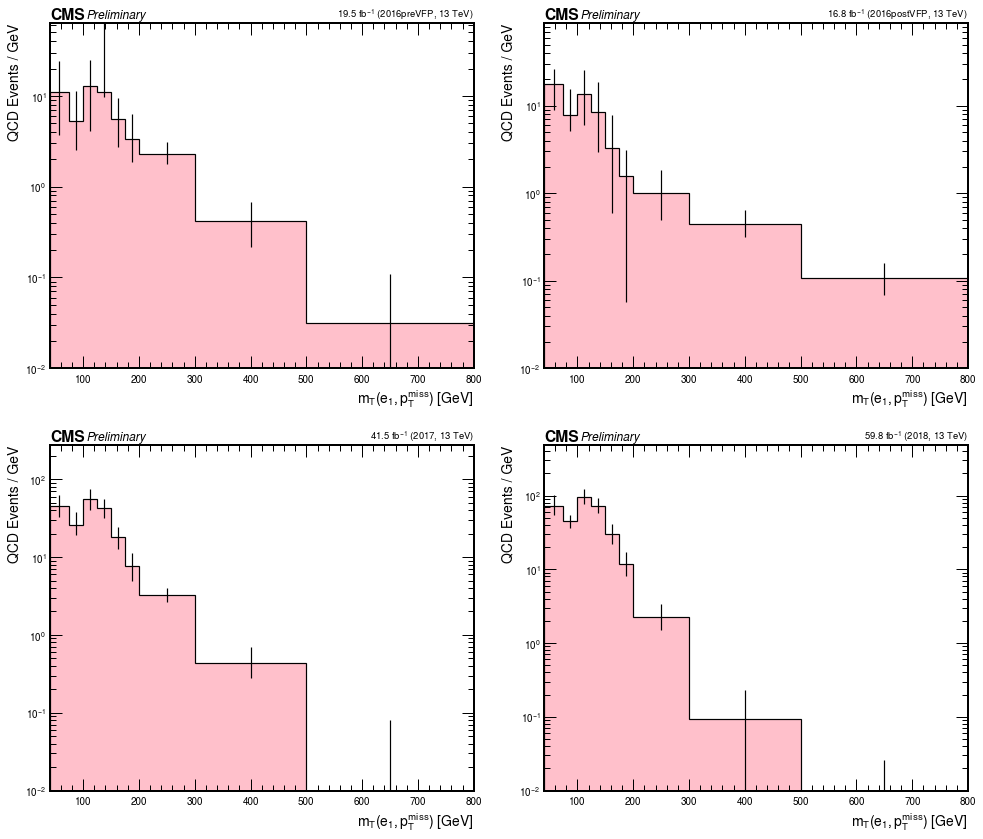

In [13]:
hep.style.use(hep.style.CMS)
energy = {"run2": "13 TeV", "run3": "13.6 TeV"}
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.markersize": 4,
    "legend.fontsize": 10,
})

variable_qcd = "electron_met_mass"
procs_qcd = ["DYJetsToLL", "SingleTop", "tt", "Diboson", "WJetsToLNu"]
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=False, sharey=False)
grid_indices = [(0, 0), (0, 1), (1, 0), (1, 1)]

qcd_store = {}

for year, (row, col) in zip(years, grid_indices):
    ax = axes[row, col]
    out_qcd = load_hists(year, "qcd_ele")
    mc_qcd_all = sum([out_qcd[p]["transverse_mass"] for p in procs_qcd if p in out_qcd])
    h_qcd_base = out_qcd["Data"]["transverse_mass"] + (mc_qcd_all * -1)
    h_qcd_cr = h_qcd_base[{"variation": "nominal"}].project(variable_qcd)
    
    tf = tf_store[year]
    h_qcd = h_qcd_cr.copy()
    h_qcd.view()[:] = np.stack([
        h_qcd_cr.values() * tf, 
        h_qcd_cr.variances() * (tf**2)
    ], axis=-1)
    
    qcd_store[year] = h_qcd.copy()
    
    widths = h_qcd.axes[0].widths
    edges = h_qcd.axes[0].edges
    centers = 0.5 * (edges[:-1] + edges[1:])
    
    #out_tf = load_hists(year, "qcd_tf_ele")
    out_tf = load_hists(year, "qcd_tf_ele")
    procs_tf = ["DYJetsToLL", "SingleTop", "tt", "Diboson"]
    available_mcs_tf = [out_tf[p]["transverse_mass"] for p in procs_tf if p in out_tf and "transverse_mass" in out_tf[p]]
    h_tf_base = out_tf["Data"]["transverse_mass"] + (accumulate(available_mcs_tf) * -1)
    axis_to_project = [ax.name for ax in h_tf_base.axes if ax.name not in ["variation", "category"]][0]
    h_Tight = h_tf_base[{"variation": "nominal", "category": "1LnT1T"}].project(axis_to_project)
    h_nTight = h_tf_base[{"variation": "nominal", "category": "1LnT1nT"}].project(axis_to_project)
    #h_Tight = h_tf_base[{"variation": "nominal", "category": "2T"}].project(axis_to_project)
    #h_nTight = h_tf_base[{"variation": "nominal", "category": "1T1L"}].project(axis_to_project)
    tf_variances = h_Tight.variances() * np.power(h_nTight.values() + 1e-32, -2)
    tf_values = np.where((h_Tight.values() > 0) & (h_nTight.values() > 0), h_Tight.values() / (h_nTight.values() + 1e-32), 1.0)
    tf_uncert = np.abs(poisson_interval(tf_values, tf_variances) - tf_values)
    err_down_normalized = (tf_uncert[0] * h_qcd_cr.values()) / widths
    err_up_normalized = (tf_uncert[1] * h_qcd_cr.values()) / widths
    yerr_poisson = np.array([err_down_normalized, err_up_normalized])
    
    h_norm = hist.Hist(h_qcd.axes[0], storage=hist.storage.Weight())
    h_norm.view()[:] = np.stack([
        h_qcd.values() / widths, 
        h_qcd.variances() / (widths**2)
    ], axis=-1)
    
    h_norm.plot1d(ax=ax, histtype="fill", color="#FFC0CB", edgecolor="black", linewidth=1.2)
    ax.errorbar(centers, h_norm.values(), yerr=yerr_poisson, fmt='none', color='black', elinewidth=1.2, capsize=0)
    
    ax.set_ylabel("QCD Events / GeV", fontsize=14)
    ax.set_xlabel(r"$m_T(e_1, p_T^{miss})$ [GeV]", fontsize=14)
    #ax.set_xlabel(r"$m_T(e, p_T^{miss})$ [GeV]", fontsize=14)
    ax.set_yscale("log")
    edges = h_norm.axes[0].edges
    ax.set_xlim(edges[0], edges[-1])
    max_val = np.max(h_norm.values()) if np.max(h_norm.values()) > 0 else 1.0
    ax.set_ylim(1e-2, max_val * 5)
    ax.tick_params(direction="in", top=True, right=True)
    
    lumi_val = luminosities[year] * 1e-3
    hep.cms.lumitext(f"{lumi_val:.1f} fb$^{{-1}}$ ({year}, {energy['run2']})", fontsize=10, ax=ax)
    hep.cms.text("Preliminary", loc=0, fontsize=12, ax=ax)

plt.tight_layout()
plt.savefig("qcd_estimated_events_Run2_Grid.png", dpi=300)
plt.show()

### INJECTION OF QCD EVENTS INTO SIGNAL REGION

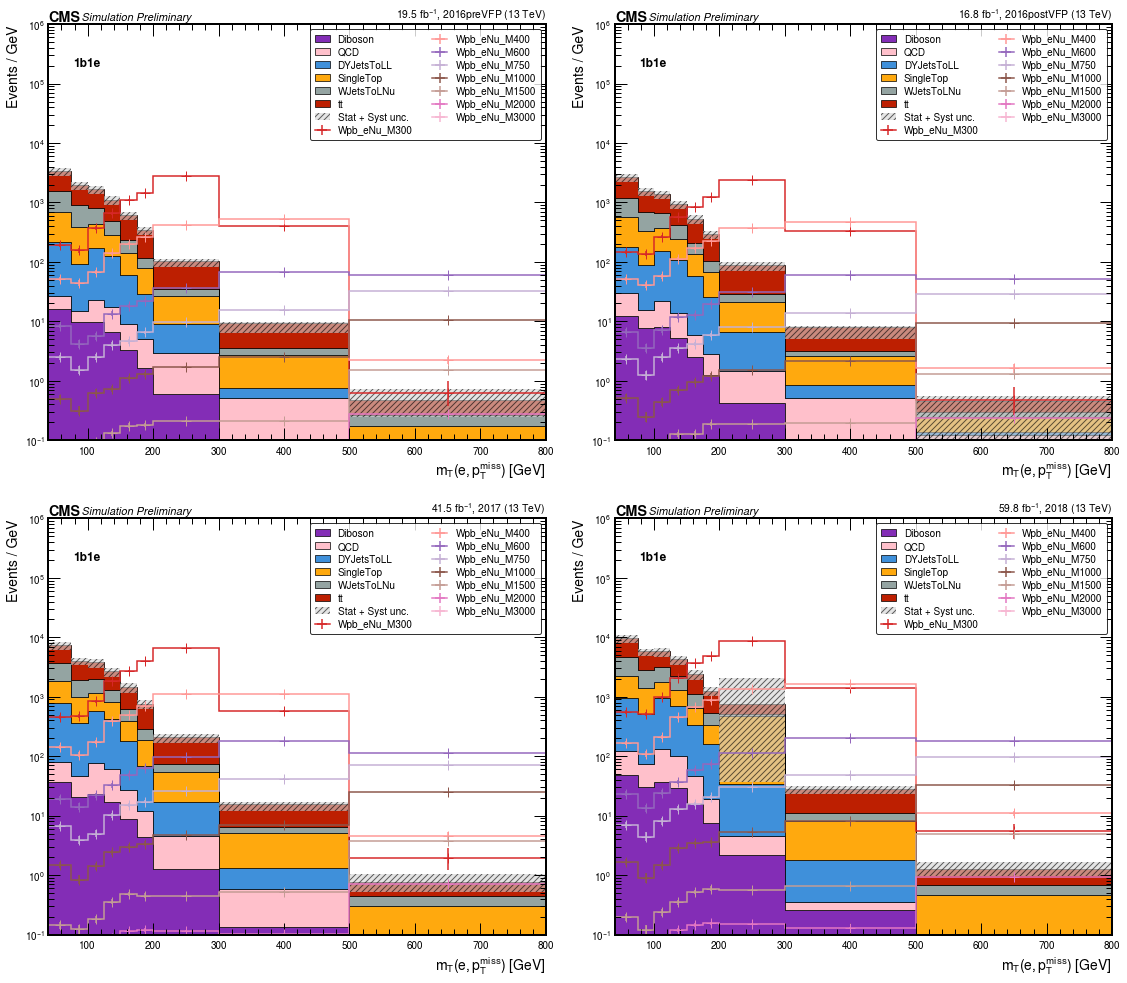

In [14]:
hep.style.use(hep.style.CMS)
energy = {"run2": "13 TeV", "run3": "13.6 TeV"}
years = ["2016preVFP", "2016postVFP", "2017", "2018"]

with open(f"{Path.cwd()}/analysis/postprocess/luminosity.yaml", "r") as f:
    luminosities = yaml.safe_load(f)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.markersize": 4,
    "legend.fontsize": 10,
})

class CoffeaPlotter:
    def __init__(self, workflow, year, processed_histograms, output_dir):
        self.workflow = workflow
        self.year = year
        self.processed_histograms = processed_histograms
        self.output_dir = output_dir
        builder = WorkflowConfigBuilder(workflow=workflow)
        self.config = builder.build_workflow_config()
        
        path = Path.cwd() / "analysis" / "postprocess"
        with open(path / "style.yaml") as f: 
            self.style = yaml.safe_load(f)
        with open(path / "color_map.yaml") as f: 
            cmap = yaml.safe_load(f)
            
        procs, _, _ = get_process_maps(self.config, year)
        self.color_map = {p: c for p, c in cmap.items() if p in procs and not p.startswith("Wpb")}
        self.color_map["QCD"] = "#FFC0CB" 
        self.signal_color_map = {p: c for p, c in cmap.items() if p.startswith("Wpb")}

    def collect_and_project(self, main_key, var_axis, category):
        h_info = {
            "mc": {"hists": [], "labels": [], "colors": [], "variations": {}}, 
            "signal": {"hists": [], "labels": [], "colors": []}, 
            "data": None
        }
        
        all_variations = set()
        for proc, h_dict in self.processed_histograms.items():
            h = h_dict.get(main_key)
            if h is not None and "variation" in h.axes.name:
                for var in h.axes["variation"]:
                    if var != "nominal":
                        all_variations.add(var)

        for proc, h_dict in self.processed_histograms.items():
            h = h_dict.get(main_key)
            if h is None: continue
            
            sel = {}
            if "variation" in h.axes.name: sel["variation"] = "nominal"
            if "category" in h.axes.name: sel["category"] = category
            
            temp_h = h[sel]
            if var_axis in temp_h.axes.name:
                temp_h = temp_h.project(var_axis)
                
            widths = temp_h.axes[0].widths
            vals = temp_h.values() / widths
            vars_ = temp_h.variances() / (widths**2)
            
            h_norm = hist.Hist(temp_h.axes[0], storage=hist.storage.Weight())
            h_norm.view()[:] = np.stack([vals, vars_], axis=-1)
                
            if proc == "Data":
                h_info["data"] = h_norm
            elif proc.startswith("Wpb"):
                h_info["signal"]["hists"].append(h_norm)
                h_info["signal"]["labels"].append(proc)
                h_info["signal"]["colors"].append(self.signal_color_map.get(proc, "black"))
            else:
                h_info["mc"]["hists"].append(h_norm)
                h_info["mc"]["labels"].append(proc)
                h_info["mc"]["colors"].append(self.color_map.get(proc, "gray"))

        for var in all_variations:
            accum_var_h = None
            for proc, h_dict in self.processed_histograms.items():
                if proc == "Data" or proc.startswith("Wpb"): 
                    continue
                
                h = h_dict.get(main_key)
                if h is None or "variation" not in h.axes.name or var not in h.axes["variation"]: 
                    continue
                
                sel = {"variation": var}
                if "category" in h.axes.name: sel["category"] = category
                
                temp_h = h[sel]
                if var_axis in temp_h.axes.name:
                    temp_h = temp_h.project(var_axis)
                
                widths = temp_h.axes[0].widths
                vals = temp_h.values() / widths
                vars_ = temp_h.variances() / (widths**2)
                
                h_norm = hist.Hist(temp_h.axes[0], storage=hist.storage.Weight())
                h_norm.view()[:] = np.stack([vals, vars_], axis=-1)
                
                if accum_var_h is None:
                    accum_var_h = h_norm
                else:
                    accum_var_h += h_norm
            
            if accum_var_h is not None:
                h_info["mc"]["variations"][var] = accum_var_h

        return h_info

    def plot_uncert_band(self, histogram_info, ax):
        safe_bins = self.nominal_values > 1e-3
        
        if histogram_info["mc"]["variations"]:
            mcstat_err2 = self.nominal_variances
            err2_up = mcstat_err2.copy()
            err2_down = mcstat_err2.copy()
            
            unique_vars = set(k[:-2] for k in histogram_info["mc"]["variations"].keys() if k.endswith("Up") or k.endswith("Down"))
            
            for variation in unique_vars:
                up_key = f"{variation}Up"
                down_key = f"{variation}Down"
                
                if up_key in histogram_info["mc"]["variations"] and down_key in histogram_info["mc"]["variations"]:
                    var_up = histogram_info["mc"]["variations"][up_key].values()
                    var_down = histogram_info["mc"]["variations"][down_key].values()
                    
                    err_up = var_up - self.nominal_values
                    err_down = var_down - self.nominal_values
                    max_delta = self.nominal_values
                    err_up = np.clip(err_up, -max_delta, max_delta)
                    err_down = np.clip(err_down, -max_delta, max_delta)
                    # -------------------------------------------------------------------------
                    
                    up_is_up = err_up > 0
                    down_is_down = err_down < 0
                    is_onesided = up_is_up ^ down_is_down
                    
                    err2_up_twosided = np.where(up_is_up, err_up**2, err_down**2)
                    err2_down_twosided = np.where(up_is_up, err_down**2, err_up**2)
                    err2_max = np.maximum(err2_up_twosided, err2_down_twosided)
                    
                    err2_up_onesided = np.where(is_onesided & up_is_up, err2_max, 0)
                    err2_down_onesided = np.where(is_onesided & down_is_down, err2_max, 0)
                    
                    err2_up_combined = np.where(is_onesided, err2_up_onesided, err2_up_twosided)
                    err2_down_combined = np.where(is_onesided, err2_down_onesided, err2_down_twosided)
                    
                    err2_up += err2_up_combined
                    err2_down += err2_down_combined
        else:
            err2_up = self.nominal_variances
            err2_down = self.nominal_variances
            
        self.band_up = self.nominal_values + np.sqrt(err2_up)
        
        sigma_down = np.sqrt(err2_down)
        self.band_down = np.where(
            sigma_down < self.nominal_values,
            self.nominal_values - sigma_down,
            self.nominal_values * 0.05
        )
        self.band_down = np.maximum(self.band_down, 1e-2)

        band_args = self.style.get("uncert_band_kwargs", {
            "label": "Stat + Syst unc.",
            "hatch": "//////",
            "facecolor": "none",
            "edgecolor": "black",
            "alpha": 0.4
        }).copy()
        
        ax.bar(
            x=self.centers[safe_bins],
            height=(self.band_up - self.band_down)[safe_bins],
            width=self.widths[safe_bins],
            bottom=self.band_down[safe_bins],
            **band_args,
        )

    def plot_histograms(self, main_key, var_axis, category, ax, log=True):
        plt.rcParams.update(self.style.get("rcParams", {}))
        
        h_info = self.collect_and_project(main_key, var_axis, category)
        mc_hists = h_info["mc"]["hists"]
        total_mc = sum(mc_hists)
        
        self.nominal_values = total_mc.values()
        self.nominal_variances = total_mc.variances()
        self.centers = total_mc.axes[0].centers
        self.widths = total_mc.axes[0].widths

        mc_stk_args = self.style.get("mc_hist_kwargs", {}).copy()
        mc_stk_args.pop("stack", None)
        mc_stk_args.pop("edgecolor", None)

        hep.histplot(
            mc_hists, 
            label=h_info["mc"]["labels"], 
            color=h_info["mc"]["colors"], 
            stack=True, 
            ax=ax, 
            edgecolor="black",
            **mc_stk_args
        )
        self.plot_uncert_band(h_info, ax)
        if h_info["signal"]["hists"]:
            for h_sig, label, color in zip(h_info["signal"]["hists"], h_info["signal"]["labels"], h_info["signal"]["colors"]):
                hep.histplot(
                    h_sig, label=label, color=color, histtype='step', ax=ax, linewidth=1.5
                )
                ax.plot(
                    h_sig.axes[0].centers, h_sig.values(), 
                    marker="+", color=color, linestyle="None", markersize=10
                )
        if h_info["data"]:
            hep.histplot(
                h_info["data"], label="Data", ax=ax, histtype='errorbar',
                color="black", marker="o", markersize=6
            )
            
        edges = total_mc.axes[0].edges
        if log:
            ax.set_yscale("log")
            ax.set_ylim(1e-1, 1e6)
        
        ax.set_xlim(edges[0], edges[-1])
        ax.tick_params(direction="in", top=True, right=True)
        
        ax.legend(ncol=2, fontsize=10, loc="upper right", frameon=True, edgecolor="black", labelspacing=0.3)
        
        lumi_val = luminosities[self.year] * 1e-3
        hep.cms.label("Preliminary", data=False, lumi=f"{lumi_val:.1f}", year=self.year, ax=ax, fontsize=11)
        
        ax.set_ylabel("Events / GeV", fontsize=14)
        ax.set_xlabel(r"$m_T(e, p_T^{miss})$ [GeV]", fontsize=14)
        ax.text(0.05, 0.90, f"{category}", transform=ax.transAxes, fontsize=12, fontweight='bold')

main_key = "mass"
variable_axis = "electron_met_mass" 
category_signal = "1b1e"

fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharex=False, sharey=False)
grid_indices = [(0, 0), (0, 1), (1, 0), (1, 1)]
all_years_histograms = {}
for year, (row, col) in zip(years, grid_indices):
    ax = axes[row, col]
    out_signal = load_hists(year, "1b1e")
    any_proc = next(p for p in out_signal.keys() if p != "Data")
    h_template_full = out_signal[any_proc][main_key]
    selector = {}
    if "variation" in h_template_full.axes.name: selector["variation"] = "nominal"
    if "category" in h_template_full.axes.name: selector["category"] = category_signal
    h_template_1d = h_template_full[selector]
    if variable_axis in h_template_1d.axes.name:
        h_template_1d = h_template_1d.project(variable_axis)
    h_qcd_inj = hist.Hist(*h_template_1d.axes, storage=hist.storage.Weight())
    h_qcd_year = qcd_store[year]
    h_qcd_inj.values()[:] = h_qcd_year.values()[:]
    h_qcd_inj.variances()[:] = h_qcd_year.variances()[:]
    
    axes_to_add = []
    if "variation" in h_template_full.axes.name:
        axes_to_add.append(hist.axis.StrCategory(["nominal"], name="variation"))
    if "category" in h_template_full.axes.name:
        axes_to_add.append(hist.axis.StrCategory([category_signal], name="category"))
    if axes_to_add:
        h_final_qcd = hist.Hist(*axes_to_add, *h_qcd_inj.axes, storage=hist.storage.Weight())
        h_final_qcd.view()[:] = h_qcd_inj.view()
    else:
        h_final_qcd = h_qcd_inj
        
    out_signal["QCD"] = {main_key: h_final_qcd}
    all_years_histograms[year] = out_signal
    plotter = CoffeaPlotter(workflow="1b1e", year=year, processed_histograms=out_signal, output_dir="./plots")
    plotter.plot_histograms(main_key, variable_axis, category_signal, ax=ax, log=True)

plt.tight_layout()
plt.savefig("signal_regions_Run2_Grid.png", dpi=300)
plt.show()

In [15]:
import pandas as pd
import numpy as np

def get_background_percentages_all_years(processed_histograms_by_year, main_key, var_axis, category):
    all_dfs = []
    
    for year, histograms in processed_histograms_by_year.items():
        background_yields = {}
        
        for proc, h_dict in histograms.items():
            if proc == "Data" or proc.startswith("Wpb"):
                continue
            if proc == "QCD":
                if isinstance(h_dict, dict) and main_key in h_dict:
                    h = h_dict[main_key]
                else:
                    h = h_dict
            else:
                if isinstance(h_dict, dict):
                    h = h_dict.get(main_key)
                else:
                    h = None
                    
            if h is None: 
                continue
            sel = {}
            if "variation" in h.axes.name and "nominal" in h.axes["variation"]: 
                sel["variation"] = "nominal"
            if "category" in h.axes.name and category in h.axes["category"]: 
                sel["category"] = category
                
            try:
                temp_h = h[sel] if sel else h
                if var_axis in temp_h.axes.name:
                    temp_h = temp_h.project(var_axis)
                total_events = temp_h.sum().value
                background_yields[proc] = total_events
            except Exception as e:
                print(f"Error in {proc} for {year}: {e}")
                continue
        
        if not background_yields:
            continue
            
        df_year = pd.DataFrame(list(background_yields.items()), columns=['Process', 'Events'])
        total_bg = df_year['Events'].sum()
        
        df_year['Percentage'] = (df_year['Events'] / (total_bg + 1e-32)) * 100
        df_year['Year'] = year
        all_dfs.append(df_year)
        print(f"\n" + "="*50)
        print(f"--- Background in {category} ({year}) ---")
        print(f"Total Background (Events): {total_bg:.2f}\n")
        
        df_print = df_year.sort_values(by='Events', ascending=False)
        print(df_print[['Process', 'Events', 'Percentage']].to_string(
            index=False, 
            formatters={'Events': '{:.2f}'.format, 'Percentage': '{:.2f}%'.format}
        ))

    print("\n" + "="*50)
    if all_dfs:
        df_total = pd.concat(all_dfs, ignore_index=True)
        df_total = df_total.sort_values(by=['Year', 'Events'], ascending=[True, False]).reset_index(drop=True)
        return df_total
    else:
        print("No background for process.")
        return pd.DataFrame()
df_composicion_total = get_background_percentages_all_years(
    processed_histograms_by_year=all_years_histograms, 
    main_key="mass", 
    var_axis="electron_met_mass", 
    category="1b1e"
)


--- Background in 1b1e (2016preVFP) ---
Total Background (Events): 273172.61

   Process    Events Percentage
        tt 151510.54     55.46%
WJetsToLNu  61569.13     22.54%
 SingleTop  39459.32     14.44%
DYJetsToLL  17552.45      6.43%
       QCD   1652.96      0.61%
   Diboson   1428.21      0.52%

--- Background in 1b1e (2016postVFP) ---
Total Background (Events): 222669.62

   Process    Events Percentage
        tt 125651.29     56.43%
WJetsToLNu  45729.08     20.54%
 SingleTop  33302.72     14.96%
DYJetsToLL  15166.39      6.81%
       QCD   1712.27      0.77%
   Diboson   1107.87      0.50%

--- Background in 1b1e (2017) ---
Total Background (Events): 605303.49

   Process    Events Percentage
        tt 315494.26     52.12%
WJetsToLNu 132031.60     21.81%
 SingleTop  88214.90     14.57%
DYJetsToLL  60564.71     10.01%
       QCD   5732.15      0.95%
   Diboson   3265.86      0.54%

--- Background in 1b1e (2018) ---
Total Background (Events): 911752.23

   Process    Events Pe